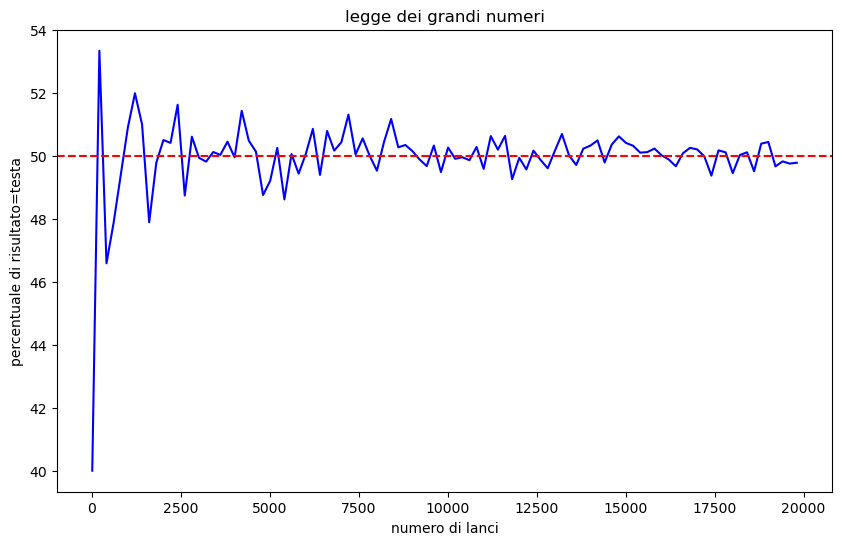

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

#1.La legge dei grandi numeri

def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()


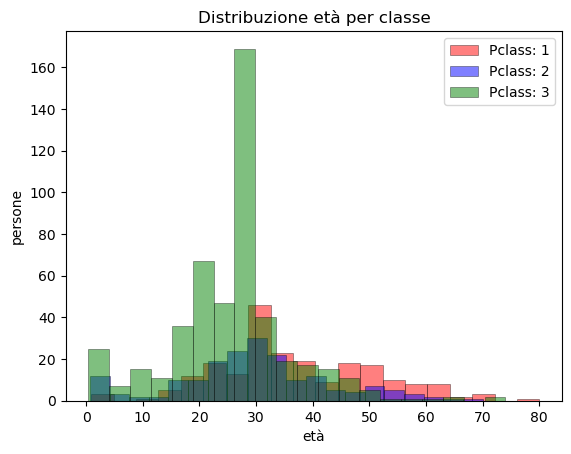

(891,
 12,
 PassengerId      0
 Survived         0
 Pclass           0
 Name             0
 Sex              0
 Age            177
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Cabin          687
 Embarked         2
 dtype: int64,
 np.int64(0),
 Pclass
 1    37.048118
 2    29.866958
 3    26.403259
 Name: Age, dtype: float64)

In [77]:
#2.Analisi del Dataset Titanic

#caricamento dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

#righe e colonne del dataset
tot_righe = df.shape[0]
tot_colonne = df.shape[1]

#valori mancanti per colonna
valori_mancanti = df.isnull().sum()

#riempire i nan in Embarked con il valore più frequente (la moda)

#prendo la moda
moda = df['Embarked'].mode()
#inserisco la moda al posto dei nan
df['Embarked'] = df['Embarked'].fillna(moda)

#controlla se ci sono righe duplicate

righe_duplicate = df.duplicated().sum() #sommo i True quindi se non ci sono duplicati devo ottenere 0

#età media per ogni classe (Pclass)

#prima assegno ai nan in 'Age' l'età media
media = df['Age'].mean()
df['Age'] = df['Age'].fillna(media)

#raggruppo per classe
media_per_classe = df.groupby('Pclass')['Age'].mean()

#distribuzione età per classe

classi = [1, 2, 3]

colori = ['red', 'blue', 'green']

for classe, colore in zip(classi, colori):
    #filtro per classe e seleziono solo la colonna Age
    subset = df[df['Pclass'] == classe]['Age']
    #alpha per avere le barre più trasparenti
    plt.hist(subset, bins=20, linewidth=0.5, alpha=0.5, edgecolor='black', color=colore, label=f'Pclass: {classe}')

plt.title('Distribuzione età per classe')
plt.xlabel('età')
plt.ylabel('persone')
plt.legend()
plt.show()

#risultati
tot_righe, tot_colonne, valori_mancanti, righe_duplicate, media_per_classe


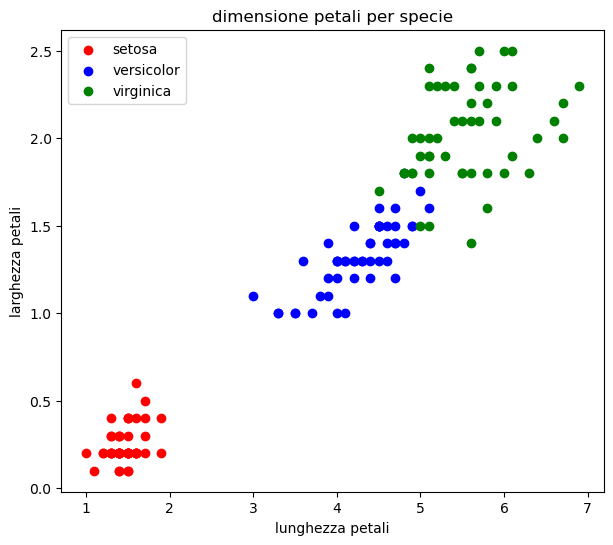

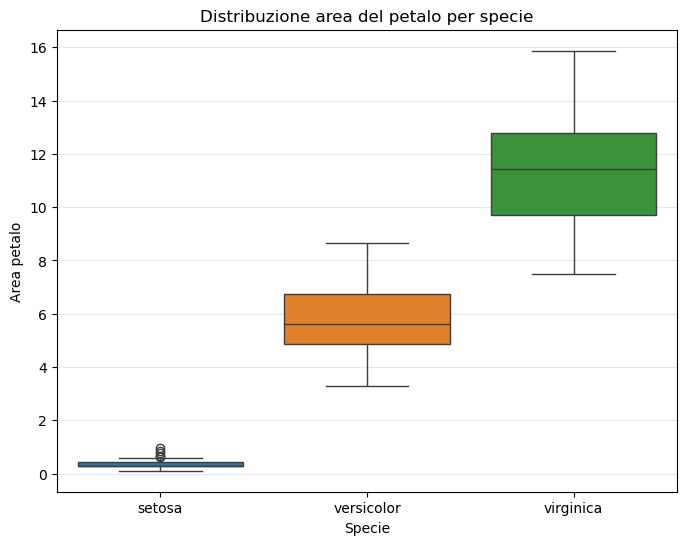

(species
 setosa        50
 versicolor    50
 virginica     50
 Name: count, dtype: int64,
 species
 setosa        1.462
 versicolor    4.260
 virginica     5.552
 Name: petal_length, dtype: float64,
 species
 setosa        0.246
 versicolor    1.326
 virginica     2.026
 Name: petal_width, dtype: float64,
    sepal_length  sepal_width  petal_length  petal_width species  petal_area
 0           5.1          3.5           1.4          0.2  setosa        0.28
 1           4.9          3.0           1.4          0.2  setosa        0.28
 2           4.7          3.2           1.3          0.2  setosa        0.26
 3           4.6          3.1           1.5          0.2  setosa        0.30
 4           5.0          3.6           1.4          0.2  setosa        0.28)

In [8]:
#3.Analisi del dataset Iris

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

#tot campioni per specie

distribuzione_specie = df['species'].value_counts()

#lunghezza e larghezza media dei petali per specie

lunghezza_petalo_media = df.groupby('species')['petal_length'].mean()
larghezza_petalo_media =df.groupby('species')['petal_width'].mean()

#scatterplot dimensione petali per specie

colors = ['red','blue','green']

plt.figure(figsize=(7,6))

for specie,colore in zip(df['species'].unique(), colors):
    #filtro per specie
    subset = df[df['species']==specie]
    plt.scatter(subset['petal_length'], subset['petal_width'], color=colore, label=specie)

plt.title('dimensione petali per specie')
plt.xlabel('lunghezza petali')
plt.ylabel('larghezza petali')
plt.legend()
plt.show()

#nuova colonna per l'area del petalo

df['petal_area'] = df['petal_length'] * df['petal_width']

#grafico distribuzione area petalo per specie

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='species', y='petal_area', hue='species')
plt.title('Distribuzione area del petalo per specie')
plt.xlabel('Specie')
plt.ylabel('Area petalo')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


#risultati
df.head()
distribuzione_specie, lunghezza_petalo_media, larghezza_petalo_media, df.head()